# TASK 3B – Descriptive Analysis

**Project:** Retail Product Demand Analysis at Fragceylon  
**Dataset:** `Fragceylon_Regular_Orders.xlsx`

This notebook performs the descriptive analysis of Fragceylon's cleaned commercial sales data.

The analysis uses Regular Orders only because Free Samples do not represent normal commercial product demand.

The main demand variable is `Quantity`.

The descriptive analysis includes:

- overall Quantity statistics
- product-level demand
- channel-level demand
- market-level demand
- monthly and yearly demand
- sales-regime comparisons
- revenue summaries
- demand visualizations
- initial business interpretations

No statistical inference or predictive modelling is performed in this notebook.

## 1. Import Required Libraries

This section imports the Python libraries required for descriptive analysis.

- `pandas` is used for data manipulation, grouping, and descriptive statistical summaries.
- `matplotlib` is used to create the demand and revenue visualizations.
- `Path` from `pathlib` is used to manage dataset and chart file locations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Load and Verify the Cleaned Regular Orders Dataset

In [2]:
cleaned_file = Path(
    "../../04_Cleaned_Data/Fragceylon_Regular_Orders.xlsx"
)

print("File exists:", cleaned_file.exists())

File exists: True


In [3]:
df = pd.read_excel(cleaned_file)

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isna().sum().sum())

Rows: 3116
Columns: 22
Missing values: 0


In [5]:
df.head()

,Order ID,Date,Product Name,Product Code,Channel Type,Buyer,Line Type,Quantity,Unit Price (LKR),Total Value (LKR),...,Year,Month,Month_Number,Quarter,Day_of_Week,Year_Month,Time_Trend,Sales_Regime,Market_Group,Is_Regular_Order
0,FC-00001,2024-10-18,Kennedy,003B,Shop,Shop_04,Regular Order,23,450.0,10350.0,...,2024,October,10,Q4,Friday,2024-10,0,Pre-April-2025,Local,1
1,FC-00002,2024-10-18,Secret Ambrosia,008A,Shop,Shop_02,Regular Order,31,450.0,13950.0,...,2024,October,10,Q4,Friday,2024-10,0,Pre-April-2025,Local,1
2,FC-00003,2024-10-18,Mesmerose,006B,Shop,Shop_15,Regular Order,35,450.0,15750.0,...,2024,October,10,Q4,Friday,2024-10,0,Pre-April-2025,Local,1
3,FC-00004,2024-10-20,Mesmerose,006B,Shop,Shop_23,Regular Order,34,450.0,15300.0,...,2024,October,10,Q4,Sunday,2024-10,2,Pre-April-2025,Local,1
4,FC-00005,2024-10-20,Kennedy,003B,Small Dealer,Ruwan Beauty Studio Gampaha,Regular Order,118,348.0,41064.0,...,2024,October,10,Q4,Sunday,2024-10,2,Pre-April-2025,Local,1


## 3. Overall Descriptive Statistics for Quantity


In [6]:
quantity = df["Quantity"]

overall_stats = pd.Series({
    "Count": quantity.count(),
    "Mean": quantity.mean(),
    "Median": quantity.median(),
    "Standard Deviation": quantity.std(),
    "Variance": quantity.var(),
    "Minimum": quantity.min(),
    "Q1": quantity.quantile(0.25),
    "Q3": quantity.quantile(0.75),
    "IQR": quantity.quantile(0.75) - quantity.quantile(0.25),
    "Maximum": quantity.max()
})

overall_stats

Count                  3116.000000
Mean                    226.511553
Median                  199.500000
Standard Deviation      183.878177
Variance              33811.184136
Minimum                  23.000000
Q1                       55.000000
Q3                      354.000000
IQR                     299.000000
Maximum                 998.000000
dtype: float64

In [7]:
overall_stats_df = overall_stats.to_frame(
    name="Quantity"
).round(2)

overall_stats_df

,Quantity
Count,3116.00
Mean,226.51
Median,199.50
Standard Deviation,183.88
Variance,33811.18
Minimum,23.00
Q1,55.00
Q3,354.00
IQR,299.00
Maximum,998.00


In [8]:
print("Mean Quantity:", round(quantity.mean(), 2))
print("Median Quantity:", round(quantity.median(), 2))

Mean Quantity: 226.51
Median Quantity: 199.5


### Initial Interpretation

The Regular Order dataset contains 3,116 commercial transactions.

The average order quantity is higher than the median order quantity, indicating that the distribution is influenced by relatively large orders.

The middle 50% of Regular Orders lies between Q1 and Q3, while the wide range between the minimum and maximum demonstrates substantial variation in order size.

This level of variability suggests that Fragceylon's commercial demand is not uniform across transactions and supports the need for further analysis by product, channel, market, and time period.

## 4. Product-Level Demand Analysis

In [9]:
product_stats = (
    df.groupby("Product Name")["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
)

product_stats["Q1"] = (
    df.groupby("Product Name")["Quantity"]
    .quantile(0.25)
)

product_stats["Q3"] = (
    df.groupby("Product Name")["Quantity"]
    .quantile(0.75)
)

product_stats["IQR"] = (
    product_stats["Q3"] - product_stats["Q1"]
)

product_stats = product_stats.round(2)

product_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR
Product Name,,,,,,,,,,
Dark Matrix,670,154120,230.03,202.0,183.55,23,984,66.0,356.00,290.00
Kennedy,851,193932,227.89,208.0,180.28,23,998,58.0,356.50,298.50
Mesmerose,975,215866,221.40,195.0,182.87,23,998,37.0,356.00,319.00
Secret Ambrosia,620,141892,228.86,196.0,190.86,23,989,67.5,340.25,272.75


In [10]:
product_stats["Demand_Share_%"] = (
    product_stats["Total_Demand"]
    / product_stats["Total_Demand"].sum()
    * 100
).round(2)

product_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Product Name,,,,,,,,,,,
Dark Matrix,670,154120,230.03,202.0,183.55,23,984,66.0,356.00,290.00,21.84
Kennedy,851,193932,227.89,208.0,180.28,23,998,58.0,356.50,298.50,27.48
Mesmerose,975,215866,221.40,195.0,182.87,23,998,37.0,356.00,319.00,30.58
Secret Ambrosia,620,141892,228.86,196.0,190.86,23,989,67.5,340.25,272.75,20.10


In [11]:
product_demand_ranking = (
    product_stats
    .sort_values("Total_Demand", ascending=False)
)

product_demand_ranking

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Product Name,,,,,,,,,,,
Mesmerose,975,215866,221.40,195.0,182.87,23,998,37.0,356.00,319.00,30.58
Kennedy,851,193932,227.89,208.0,180.28,23,998,58.0,356.50,298.50,27.48
Dark Matrix,670,154120,230.03,202.0,183.55,23,984,66.0,356.00,290.00,21.84
Secret Ambrosia,620,141892,228.86,196.0,190.86,23,989,67.5,340.25,272.75,20.10


In [12]:
product_summary = product_demand_ranking[
    [
        "Count",
        "Total_Demand",
        "Demand_Share_%",
        "Mean",
        "Median",
        "Std_Dev",
        "Minimum",
        "Maximum"
    ]
]

product_summary

,Count,Total_Demand,Demand_Share_%,Mean,Median,Std_Dev,Minimum,Maximum
Product Name,,,,,,,,
Mesmerose,975,215866,30.58,221.40,195.0,182.87,23,998
Kennedy,851,193932,27.48,227.89,208.0,180.28,23,998
Dark Matrix,670,154120,21.84,230.03,202.0,183.55,23,984
Secret Ambrosia,620,141892,20.10,228.86,196.0,190.86,23,989


### Product-Level Interpretation

The product-level descriptive statistics show how total demand, average order size, median order size, and variability differ across the four perfumes.

The ranking by total demand identifies which products contributed the largest and smallest shares of commercial demand during the observed period.

Differences in mean, median, and standard deviation also indicate whether some products tend to have larger or more variable order quantities than others.

These results are descriptive only. Statistical significance of product differences will be evaluated later during the statistical inference stage.

## 5. Channel-Level Demand Analysis

In [13]:
channel_stats = (
    df.groupby("Channel Type")["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
)

channel_stats["Q1"] = (
    df.groupby("Channel Type")["Quantity"]
    .quantile(0.25)
)

channel_stats["Q3"] = (
    df.groupby("Channel Type")["Quantity"]
    .quantile(0.75)
)

channel_stats["IQR"] = (
    channel_stats["Q3"] - channel_stats["Q1"]
)

channel_stats = channel_stats.round(2)

channel_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR
Channel Type,,,,,,,,,,
Main Dealer,2014,622595,309.13,298.0,172.20,51,998,173.0,417.0,244.0
Shop,751,22449,29.89,30.0,4.26,23,37,26.0,34.0,8.0
Small Dealer,351,60766,173.12,179.0,72.38,51,299,103.0,234.5,131.5


In [14]:
channel_stats["Demand_Share_%"] = (
    channel_stats["Total_Demand"]
    / channel_stats["Total_Demand"].sum()
    * 100
).round(2)

channel_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Channel Type,,,,,,,,,,,
Main Dealer,2014,622595,309.13,298.0,172.20,51,998,173.0,417.0,244.0,88.21
Shop,751,22449,29.89,30.0,4.26,23,37,26.0,34.0,8.0,3.18
Small Dealer,351,60766,173.12,179.0,72.38,51,299,103.0,234.5,131.5,8.61


In [15]:
channel_demand_ranking = (
    channel_stats
    .sort_values("Total_Demand", ascending=False)
)

channel_demand_ranking

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Channel Type,,,,,,,,,,,
Main Dealer,2014,622595,309.13,298.0,172.20,51,998,173.0,417.0,244.0,88.21
Small Dealer,351,60766,173.12,179.0,72.38,51,299,103.0,234.5,131.5,8.61
Shop,751,22449,29.89,30.0,4.26,23,37,26.0,34.0,8.0,3.18


In [16]:
channel_summary = channel_demand_ranking[
    [
        "Count",
        "Total_Demand",
        "Demand_Share_%",
        "Mean",
        "Median",
        "Std_Dev",
        "Minimum",
        "Maximum"
    ]
]

channel_summary

,Count,Total_Demand,Demand_Share_%,Mean,Median,Std_Dev,Minimum,Maximum
Channel Type,,,,,,,,
Main Dealer,2014,622595,88.21,309.13,298.0,172.20,51,998
Small Dealer,351,60766,8.61,173.12,179.0,72.38,51,299
Shop,751,22449,3.18,29.89,30.0,4.26,23,37


### Channel-Level Interpretation

The channel-level descriptive statistics show differences in total demand, typical order size, and demand variability across Shop, Small Dealer, and Main Dealer transactions.

However, the channel structure changed during the historical period. Shop and Small Dealer transactions belong to the earlier sales regime, while Main Dealer transactions belong to the later regime.

Therefore, the observed differences should be interpreted as differences across channel structures and historical business periods rather than as evidence that a particular sales channel directly caused higher or lower demand.

Formal statistical testing of channel differences will be performed later during the statistical inference stage.

## 6. Market-Level Demand Analysis

In [17]:
market_stats = (
    df.groupby("Export Market")["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
)

market_stats["Q1"] = (
    df.groupby("Export Market")["Quantity"]
    .quantile(0.25)
)

market_stats["Q3"] = (
    df.groupby("Export Market")["Quantity"]
    .quantile(0.75)
)

market_stats["IQR"] = (
    market_stats["Q3"] - market_stats["Q1"]
)

market_stats["Demand_Share_%"] = (
    market_stats["Total_Demand"]
    / market_stats["Total_Demand"].sum()
    * 100
)

market_stats = market_stats.round(2)

market_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Export Market,,,,,,,,,,,
Japan,185,115168,622.53,623.0,212.40,209,998,468.0,783.0,315.0,16.32
Local,2931,590642,201.52,181.0,150.28,23,499,37.0,323.5,286.5,83.68


In [18]:
market_summary = market_stats[
    [
        "Count",
        "Total_Demand",
        "Demand_Share_%",
        "Mean",
        "Median",
        "Std_Dev",
        "Minimum",
        "Maximum"
    ]
].sort_values(
    "Total_Demand",
    ascending=False
)

market_summary

,Count,Total_Demand,Demand_Share_%,Mean,Median,Std_Dev,Minimum,Maximum
Export Market,,,,,,,,
Local,2931,590642,83.68,201.52,181.0,150.28,23,499
Japan,185,115168,16.32,622.53,623.0,212.40,209,998


### Market-Level Interpretation

The market-level statistics describe differences in commercial demand between Local and Japan orders.

The Japan observations are structurally concentrated within one buyer, the Main Dealer channel, and the post-April-2025 business regime. Therefore, any observed Local–Japan differences represent associations within the available historical data and should not be interpreted as isolated causal market effects.

Formal testing of market differences will be performed later during statistical inference.

## 7. Monthly Demand Analysis

In [19]:
monthly_stats = (
    df.groupby(["Month_Number", "Month"])["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std"
    )
    .reset_index()
    .sort_values("Month_Number")
)

monthly_stats = monthly_stats.round(2)

monthly_stats

,Month_Number,Month,Count,Total_Demand,Mean,Median,Std_Dev
0,1,January,704,133944,190.26,141.0,176.19
1,2,February,103,21616,209.86,201.0,172.14
2,3,March,289,53362,184.64,138.0,169.41
3,4,April,667,210758,315.98,298.0,183.66
4,5,May,78,25829,331.14,327.5,197.00
5,6,June,64,19753,308.64,320.5,153.91
6,7,July,9,2983,331.44,378.0,161.78
7,8,August,23,7002,304.43,289.0,186.04
8,9,September,38,11286,297.00,287.5,148.28
9,10,October,71,13642,192.14,152.0,149.57


In [20]:
monthly_stats["Demand_Share_%"] = (
    monthly_stats["Total_Demand"]
    / monthly_stats["Total_Demand"].sum()
    * 100
).round(2)

monthly_stats

,Month_Number,Month,Count,Total_Demand,Mean,Median,Std_Dev,Demand_Share_%
0,1,January,704,133944,190.26,141.0,176.19,18.98
1,2,February,103,21616,209.86,201.0,172.14,3.06
2,3,March,289,53362,184.64,138.0,169.41,7.56
3,4,April,667,210758,315.98,298.0,183.66,29.86
4,5,May,78,25829,331.14,327.5,197.00,3.66
5,6,June,64,19753,308.64,320.5,153.91,2.80
6,7,July,9,2983,331.44,378.0,161.78,0.42
7,8,August,23,7002,304.43,289.0,186.04,0.99
8,9,September,38,11286,297.00,287.5,148.28,1.60
9,10,October,71,13642,192.14,152.0,149.57,1.93


In [21]:
highest_month = monthly_stats.loc[
    monthly_stats["Total_Demand"].idxmax()
]

lowest_month = monthly_stats.loc[
    monthly_stats["Total_Demand"].idxmin()
]

print("Highest-demand month:")
print(highest_month)

print("\nLowest-demand month:")
print(lowest_month)

Highest-demand month:
Month_Number           4
Month              April
Count                667
Total_Demand      210758
Mean              315.98
Median             298.0
Std_Dev           183.66
Demand_Share_%     29.86
Name: 3, dtype: object

Lowest-demand month:
Month_Number           7
Month               July
Count                  9
Total_Demand        2983
Mean              331.44
Median             378.0
Std_Dev           161.78
Demand_Share_%      0.42
Name: 6, dtype: object


### Monthly Analysis Interpretation

Monthly demand totals provide an initial indication of how commercial demand varies across the calendar year.

However, the dataset does not contain the same number of complete observations for every calendar month. The historical period begins in October 2024 and ends in June 2026, so some months are represented more often than others.

For this reason, monthly totals are treated as descriptive evidence of demand patterns rather than as definitive seasonal effects. More detailed chronological analysis is performed using Year-Month periods.

## 8. Year-Month Demand Analysis

In [22]:
year_month_stats = (
    df.groupby("Year_Month")["Quantity"]
    .agg(
        Order_Count="count",
        Total_Demand="sum",
        Mean_Order_Quantity="mean",
        Median_Order_Quantity="median"
    )
    .reset_index()
    .sort_values("Year_Month")
)

year_month_stats = year_month_stats.round(2)

year_month_stats

,Year_Month,Order_Count,Total_Demand,Mean_Order_Quantity,Median_Order_Quantity
0,2024-10,27,1556,57.63,34.0
1,2024-11,148,12044,81.38,34.0
2,2024-12,377,28450,75.46,33.0
3,2025-01,364,27557,75.71,33.0
4,2025-02,45,3717,82.60,35.0
5,2025-03,141,9891,70.15,35.0
6,2025-04,335,103212,308.10,286.0
7,2025-05,37,13588,367.24,361.0
8,2025-06,22,7119,323.59,319.0
9,2025-07,9,2983,331.44,378.0


In [23]:
highest_year_month = year_month_stats.loc[
    year_month_stats["Total_Demand"].idxmax()
]

lowest_year_month = year_month_stats.loc[
    year_month_stats["Total_Demand"].idxmin()
]

print("Highest-demand Year-Month:")
print(highest_year_month)

print("\nLowest-demand Year-Month:")
print(lowest_year_month)

Highest-demand Year-Month:
Year_Month               2025-12
Order_Count                  395
Total_Demand              115818
Mean_Order_Quantity       293.21
Median_Order_Quantity      280.0
Name: 14, dtype: object

Lowest-demand Year-Month:
Year_Month               2024-10
Order_Count                   27
Total_Demand                1556
Mean_Order_Quantity        57.63
Median_Order_Quantity       34.0
Name: 0, dtype: object


### Year-Month Interpretation

Year-Month aggregation provides a more reliable chronological view of demand than combining all observations from the same calendar month.

Changes in monthly total demand may reflect product demand, the number of orders, business growth, dealer activity, market changes, or the April 2025 channel restructuring.

Therefore, large changes between periods should be interpreted together with the historical business context rather than being attributed automatically to seasonality.

## 9. Year-Level Demand Analysis

In [24]:
year_stats = (
    df.groupby("Year")["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
)

year_stats["Demand_Share_%"] = (
    year_stats["Total_Demand"]
    / year_stats["Total_Demand"].sum()
    * 100
)

year_stats = year_stats.round(2)

year_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Demand_Share_%
Year,,,,,,,,
2024,552,42050,76.18,33.0,78.08,23,296,5.96
2025,1603,363582,226.81,196.0,184.06,23,998,51.51
2026,961,300178,312.36,303.0,171.19,51,998,42.53


### Year-Level Interpretation

Annual summaries describe how the recorded demand is distributed across the available calendar years.

However, 2024 and 2026 are incomplete years in the dataset. Therefore, differences in total annual demand should not be interpreted as direct year-over-year growth or decline without accounting for unequal observation periods.

## 10. Sales Regime Analysis

In [25]:
regime_stats = (
    df.groupby("Sales_Regime")["Quantity"]
    .agg(
        Count="count",
        Total_Demand="sum",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
)

regime_stats["Q1"] = (
    df.groupby("Sales_Regime")["Quantity"]
    .quantile(0.25)
)

regime_stats["Q3"] = (
    df.groupby("Sales_Regime")["Quantity"]
    .quantile(0.75)
)

regime_stats["IQR"] = (
    regime_stats["Q3"] - regime_stats["Q1"]
)

regime_stats["Demand_Share_%"] = (
    regime_stats["Total_Demand"]
    / regime_stats["Total_Demand"].sum()
    * 100
)

regime_stats = regime_stats.round(2)

regime_stats

,Count,Total_Demand,Mean,Median,Std_Dev,Minimum,Maximum,Q1,Q3,IQR,Demand_Share_%
Sales_Regime,,,,,,,,,,,
Post-April-2025,2014,622595,309.13,298.0,172.20,51,998,173.0,417.0,244.0,88.21
Pre-April-2025,1102,83215,75.51,33.0,78.33,23,299,28.0,98.0,70.0,11.79


### Sales Regime Interpretation

The pre- and post-April-2025 periods represent different channel structures.

The earlier period contains Shop and Small Dealer transactions, while the later period contains Main Dealer transactions.

Therefore, differences in order quantity between the two regimes may reflect a combination of business-process changes, dealer structure, market composition, and demand behaviour.

The comparison is descriptive and should not be interpreted as evidence that the regime change itself caused the observed difference in demand.

## 11. Revenue Descriptive Analysis

In [26]:
revenue = df["Total Value (LKR)"]

revenue_stats = pd.Series({
    "Total Revenue (LKR)": revenue.sum(),
    "Mean Transaction Value (LKR)": revenue.mean(),
    "Median Transaction Value (LKR)": revenue.median(),
    "Standard Deviation (LKR)": revenue.std(),
    "Minimum Transaction Value (LKR)": revenue.min(),
    "Maximum Transaction Value (LKR)": revenue.max()
}).round(2)

revenue_stats

Total Revenue (LKR)                2.467083e+08
Mean Transaction Value (LKR)       7.917467e+04
Median Transaction Value (LKR)     6.820800e+04
Standard Deviation (LKR)           6.245359e+04
Minimum Transaction Value (LKR)    9.832500e+03
Maximum Transaction Value (LKR)    3.473040e+05
dtype: float64

### 11.1 Revenue by Product

Revenue is summarized across the four perfume products to identify how much transaction value each product contributed during the observed period.

Revenue results are interpreted separately from demand because a product's financial contribution depends on both Quantity and Unit Price.

In [27]:
product_revenue = (
    df.groupby("Product Name")["Total Value (LKR)"]
    .agg(
        Order_Count="count",
        Total_Revenue="sum",
        Mean_Transaction_Value="mean",
        Median_Transaction_Value="median"
    )
)

product_revenue["Revenue_Share_%"] = (
    product_revenue["Total_Revenue"]
    / product_revenue["Total_Revenue"].sum()
    * 100
)

product_revenue = (
    product_revenue
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

product_revenue

,Order_Count,Total_Revenue,Mean_Transaction_Value,Median_Transaction_Value,Revenue_Share_%
Product Name,,,,,
Mesmerose,975,75529324.6,77465.97,67512.0,30.61
Kennedy,851,67786469.5,79655.08,71688.0,27.48
Dark Matrix,670,53821303.4,80330.30,68434.2,21.82
Secret Ambrosia,620,49571160.3,79953.48,66120.0,20.09


### 11.2 Revenue by Channel

Revenue is summarized across Shop, Small Dealer, and Main Dealer transactions.

Because the sales-channel structure changed around April 2025, channel-level revenue differences are interpreted together with the historical sales regime rather than as isolated channel effects.

In [28]:
channel_revenue = (
    df.groupby("Channel Type")["Total Value (LKR)"]
    .agg(
        Order_Count="count",
        Total_Revenue="sum",
        Mean_Transaction_Value="mean",
        Median_Transaction_Value="median"
    )
)

channel_revenue["Revenue_Share_%"] = (
    channel_revenue["Total_Revenue"]
    / channel_revenue["Total_Revenue"].sum()
    * 100
)

channel_revenue = (
    channel_revenue
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

channel_revenue

,Order_Count,Total_Revenue,Mean_Transaction_Value,Median_Transaction_Value,Revenue_Share_%
Channel Type,,,,,
Main Dealer,2014,215305579.0,106904.46,103077.6,87.27
Small Dealer,351,21467511.3,61161.00,61596.0,8.70
Shop,751,9935167.5,13229.25,13050.0,4.03


### 11.3 Revenue by Market

Revenue is compared between Local and Japan Regular Orders.

The Japan market results require cautious interpretation because all Japan records are associated with one Main Dealer buyer and the post-April-2025 sales regime.

In [29]:
market_revenue = (
    df.groupby("Export Market")["Total Value (LKR)"]
    .agg(
        Order_Count="count",
        Total_Revenue="sum",
        Mean_Transaction_Value="mean",
        Median_Transaction_Value="median"
    )
)

market_revenue["Revenue_Share_%"] = (
    market_revenue["Total_Revenue"]
    / market_revenue["Total_Revenue"].sum()
    * 100
)

market_revenue = (
    market_revenue
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

market_revenue

,Order_Count,Total_Revenue,Mean_Transaction_Value,Median_Transaction_Value,Revenue_Share_%
Export Market,,,,,
Local,2931,206956548.4,70609.54,62640.0,83.89
Japan,185,39751709.4,214874.10,216108.0,16.11


### 11.4 Revenue by Year-Month

Revenue is aggregated chronologically by `Year_Month` to examine how the financial value of Regular Orders changes over the historical period.

Year-Month aggregation avoids combining the same calendar month from different years and preserves the sequence of business activity.

In [30]:
monthly_revenue = (
    df.groupby("Year_Month")["Total Value (LKR)"]
    .agg(
        Order_Count="count",
        Total_Revenue="sum",
        Mean_Transaction_Value="mean"
    )
    .reset_index()
    .sort_values("Year_Month")
)

monthly_revenue = monthly_revenue.round(2)

monthly_revenue

,Year_Month,Order_Count,Total_Revenue,Mean_Transaction_Value
0,2024-10,27,641550.0,23761.11
1,2024-11,148,4565040.0,30844.86
2,2024-12,377,10888980.0,28883.24
3,2025-01,364,10010932.8,27502.56
4,2025-02,45,1412040.0,31378.67
5,2025-03,141,3884136.0,27547.06
6,2025-04,335,36011088.0,107495.79
7,2025-05,37,4737840.0,128049.73
8,2025-06,22,2480324.0,112742.00
9,2025-07,9,1041092.0,115676.89


In [31]:
highest_revenue_month = monthly_revenue.loc[
    monthly_revenue["Total_Revenue"].idxmax()
]

lowest_revenue_month = monthly_revenue.loc[
    monthly_revenue["Total_Revenue"].idxmin()
]

print("Highest-revenue Year-Month:")
print(highest_revenue_month)

print("\nLowest-revenue Year-Month:")
print(lowest_revenue_month)

Highest-revenue Year-Month:
Year_Month                   2025-12
Order_Count                      395
Total_Revenue             40420824.0
Mean_Transaction_Value      102331.2
Name: 14, dtype: object

Lowest-revenue Year-Month:
Year_Month                 2024-10
Order_Count                     27
Total_Revenue             641550.0
Mean_Transaction_Value    23761.11
Name: 0, dtype: object


### Revenue Analysis Interpretation

Revenue analysis complements the Quantity-based demand analysis by showing the financial value associated with Regular Orders.

Differences in revenue across products, channels, markets, and months reflect a combination of order quantities and applicable pricing rules.

Revenue should therefore not be interpreted as an independent measure of demand. In particular, channel-level and market-level revenue comparisons must be considered together with the April 2025 business-structure change and the concentration of Japan transactions within one Main Dealer buyer.

These revenue summaries provide descriptive business context and will later support the development of management recommendations.

## 12. Demand Visualizations

Visualizations are used to complement the descriptive statistics and make important demand patterns easier to interpret.

The charts in this section examine:

- total demand by product
- average order quantity by product
- monthly demand over time
- product demand over time
- Quantity distribution
- Quantity outliers
- channel-level demand
- Local versus Japan demand
- monthly revenue

All visualizations use Regular Orders only unless otherwise stated.

In [32]:
chart_folder = Path("../../06_Charts")

chart_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Chart folder:", chart_folder.resolve())

Chart folder: C:\Users\saths\Desktop\Sliit\3rd year\3rd Year 1st sem\IT3081-SM\Project\IT3081-Fragceylon-Retail-Demand-Analysis\06_Charts


### 12.1 Total Demand by Product

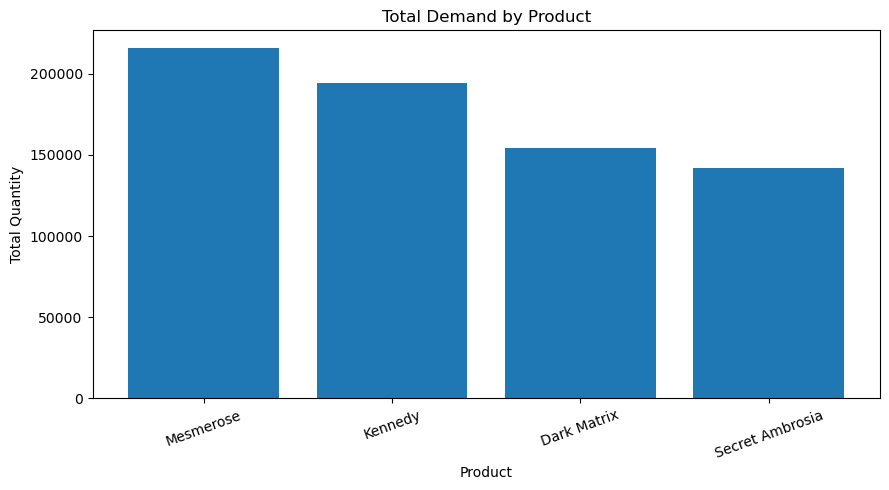

In [33]:
product_total_demand = (
    df.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_total_demand.index,
    product_total_demand.values
)

plt.title("Total Demand by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    chart_folder / "01_Total_Demand_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The chart shows the relative contribution of each perfume product to total commercial demand during the observed period.

Products with higher bars contributed a greater number of units to overall Regular Order demand.

The chart provides a descriptive ranking of product demand. Statistical significance of differences between products will be evaluated later during statistical inference.

### 12.2 Average Order Quantity by Product

This chart compares the mean Quantity per Regular Order for each perfume.

Unlike total demand, average order quantity focuses on the typical size of an individual commercial order.

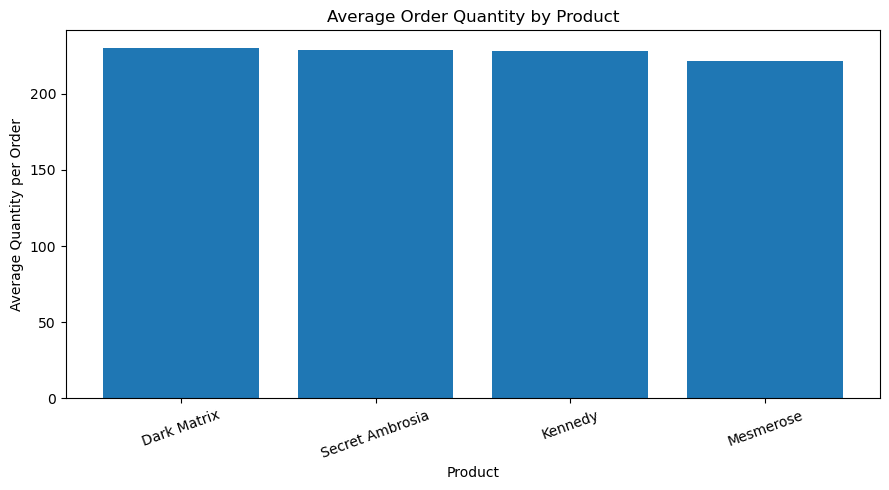

In [34]:
product_mean_quantity = (
    df.groupby("Product Name")["Quantity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_mean_quantity.index,
    product_mean_quantity.values
)

plt.title("Average Order Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Average Quantity per Order")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    chart_folder / "02_Average_Order_Quantity_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Average order quantity provides a different perspective from total demand.

A product may have high total demand because it appears in many orders, because its individual orders are relatively large, or because of a combination of both factors.

Comparing average order quantity across products therefore helps distinguish order-size behaviour from total accumulated demand.

In [35]:
monthly_demand_plot = (
    df.groupby("Year_Month")["Quantity"]
    .sum()
    .reset_index(name="Total_Demand")
)

monthly_demand_plot["Month_Date"] = pd.to_datetime(
    monthly_demand_plot["Year_Month"] + "-01"
)

monthly_demand_plot = monthly_demand_plot.sort_values(
    "Month_Date"
)

monthly_demand_plot

,Year_Month,Total_Demand,Month_Date
0,2024-10,1556,2024-10-01
1,2024-11,12044,2024-11-01
2,2024-12,28450,2024-12-01
3,2025-01,27557,2025-01-01
4,2025-02,3717,2025-02-01
5,2025-03,9891,2025-03-01
6,2025-04,103212,2025-04-01
7,2025-05,13588,2025-05-01
8,2025-06,7119,2025-06-01
9,2025-07,2983,2025-07-01


### 12.3 Monthly Total Demand Over Time

Regular Order Quantity is aggregated by Year-Month to examine how commercial demand changed chronologically between October 2024 and June 2026.

Year-Month is used instead of calendar month alone so that the sequence of historical demand is preserved.

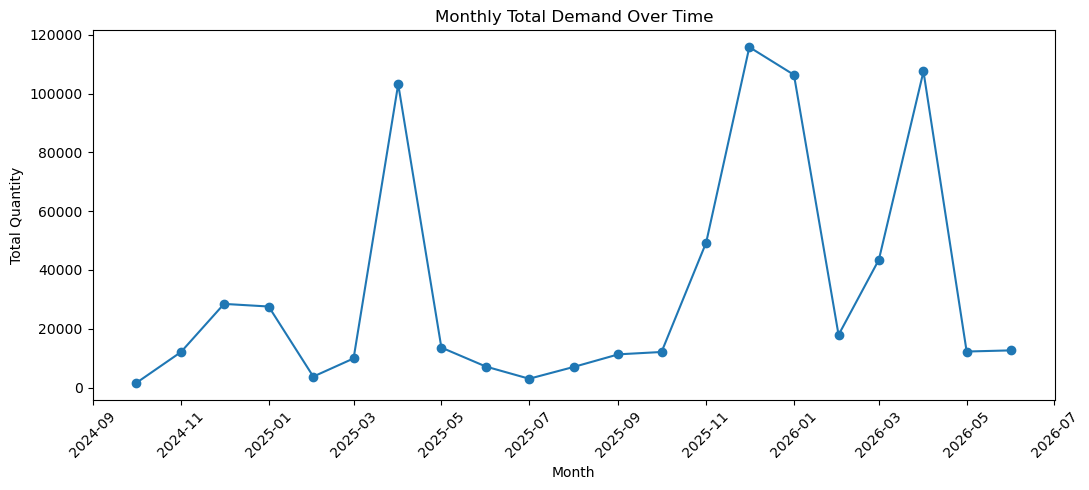

In [36]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_demand_plot["Month_Date"],
    monthly_demand_plot["Total_Demand"],
    marker="o"
)

plt.title("Monthly Total Demand Over Time")
plt.xlabel("Month")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    chart_folder / "03_Monthly_Total_Demand_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The monthly demand trend shows that commercial demand varies across the historical period rather than remaining constant.

Changes in monthly demand may reflect changes in order frequency, order size, product demand, dealer activity, market composition, seasonal effects, or the business-structure change around April 2025.

Therefore, visible peaks and declines are treated as historical demand patterns rather than being attributed automatically to seasonality or a single business factor.

### 12.4 Product Demand Over Time

Monthly demand is separated by perfume product to examine whether the four products follow similar or different historical demand patterns.

This chart helps identify product-specific peaks, declines, and differences in demand behaviour over time.

In [37]:
product_monthly_demand = (
    df.groupby(
        ["Year_Month", "Product Name"]
    )["Quantity"]
    .sum()
    .reset_index(name="Total_Demand")
)

product_monthly_demand["Month_Date"] = pd.to_datetime(
    product_monthly_demand["Year_Month"] + "-01"
)

product_monthly_demand = product_monthly_demand.sort_values(
    "Month_Date"
)

product_monthly_demand.head()

,Year_Month,Product Name,Total_Demand,Month_Date
0,2024-10,Dark Matrix,416,2024-10-01
1,2024-10,Kennedy,525,2024-10-01
2,2024-10,Mesmerose,453,2024-10-01
3,2024-10,Secret Ambrosia,162,2024-10-01
4,2024-11,Dark Matrix,2824,2024-11-01


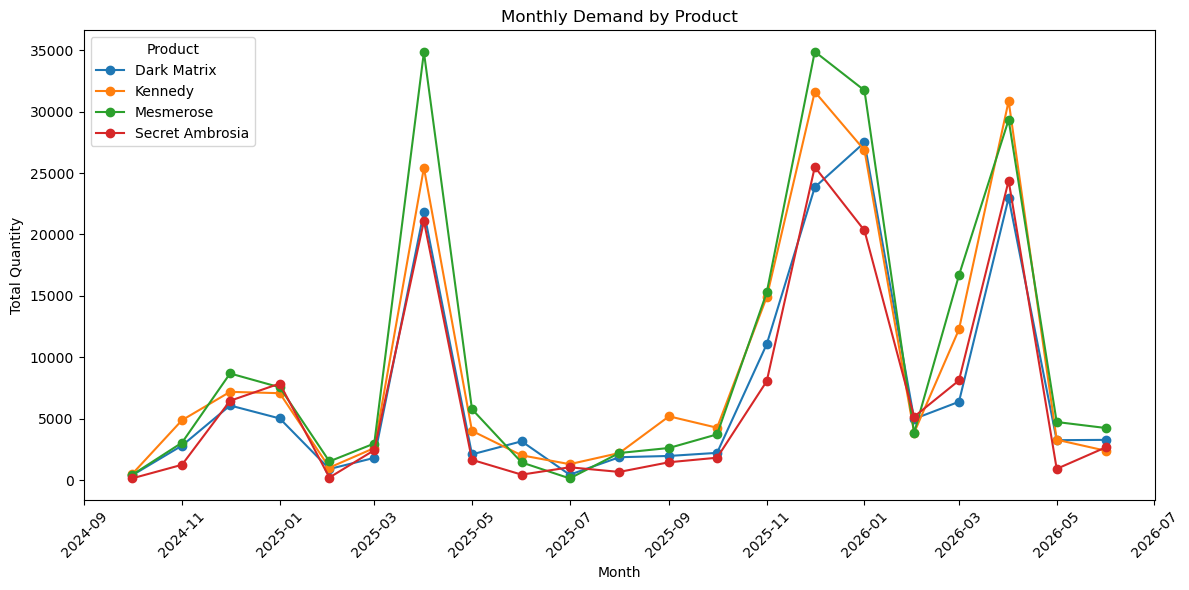

In [38]:
plt.figure(figsize=(12, 6))

for product in sorted(
    product_monthly_demand["Product Name"].unique()
):
    product_data = product_monthly_demand[
        product_monthly_demand["Product Name"] == product
    ]

    plt.plot(
        product_data["Month_Date"],
        product_data["Total_Demand"],
        marker="o",
        label=product
    )

plt.title("Monthly Demand by Product")
plt.xlabel("Month")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)
plt.legend(title="Product")

plt.tight_layout()

plt.savefig(
    chart_folder / "04_Monthly_Demand_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The product-level time series allows monthly demand patterns to be compared across the four perfumes.

Differences in the timing and magnitude of demand peaks may indicate that the products do not follow identical demand patterns.

These observations remain descriptive and will later be considered alongside statistical testing and the historical business context.

In [39]:
for file in sorted(chart_folder.glob("*.png")):
    print(file.name)

01_Total_Demand_by_Product.png
02_Average_Order_Quantity_by_Product.png
03_Monthly_Total_Demand_Over_Time.png
04_Monthly_Demand_by_Product.png


### 12.5 Distribution of Regular Order Quantity

A histogram is used to examine the distribution of `Quantity` across the 3,116 Regular Orders.

This visualization helps assess the overall shape of commercial order sizes and whether the distribution appears symmetric or influenced by relatively large orders.

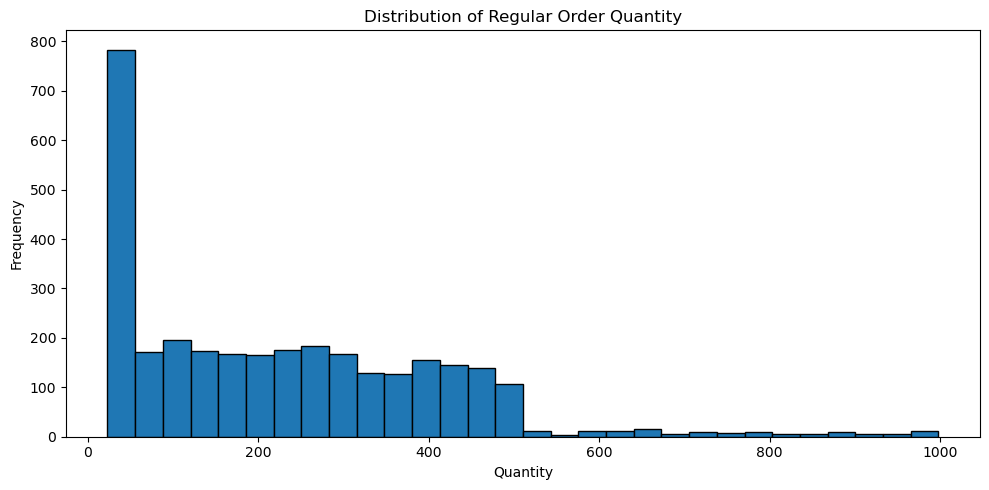

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Quantity"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Regular Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    chart_folder / "05_Quantity_Histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The histogram shows the overall distribution of Regular Order quantities.

The distribution contains a concentration of smaller and moderate order quantities together with a smaller number of very large orders.

This is consistent with the descriptive statistics, where the mean Quantity is higher than the median, suggesting that relatively large orders influence the upper end of the distribution.

### 12.6 Overall Quantity Boxplot

A boxplot is used to summarize the distribution of Regular Order Quantity and visually identify observations that fall beyond the conventional IQR-based whiskers.

The boxplot complements the numerical outlier analysis performed during data cleaning.

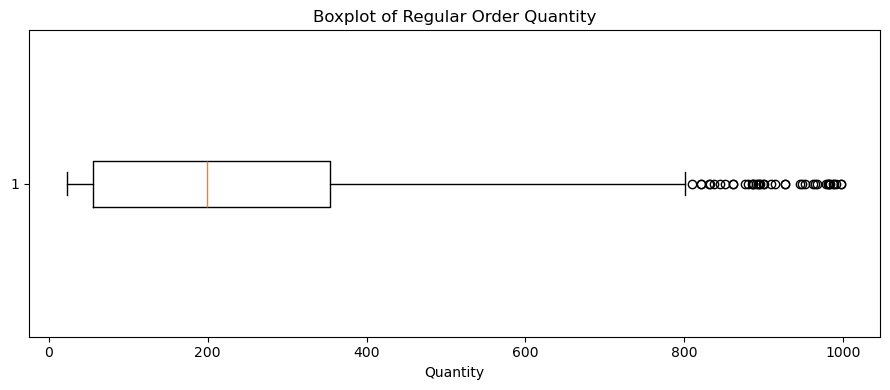

In [41]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    df["Quantity"],
    vert=False
)

plt.title("Boxplot of Regular Order Quantity")
plt.xlabel("Quantity")

plt.tight_layout()

plt.savefig(
    chart_folder / "06_Quantity_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The boxplot confirms that a number of Regular Orders lie above the upper range of the central distribution.

These observations correspond to the high-Quantity orders identified during the IQR audit.

They were retained because they form a consistent Japan Main Dealer pattern and passed the pricing and Total Value validation checks.

### 12.7 Quantity Distribution by Product

Separate boxplots are used to compare the distribution of Regular Order Quantity across the four perfume products.

This visualization highlights differences in median order size, variability, and extreme observations between products.

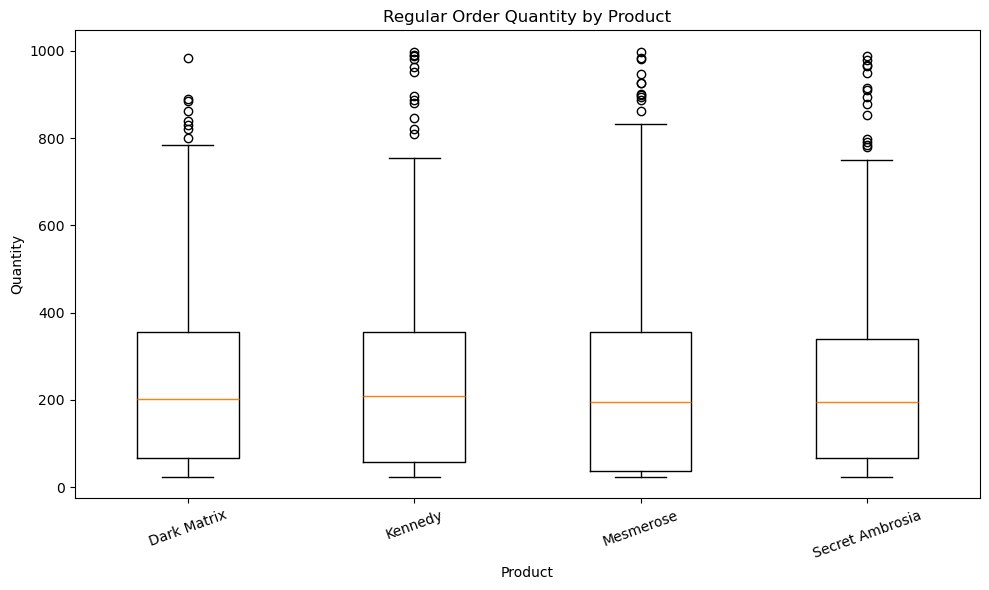

In [42]:
product_names = sorted(df["Product Name"].unique())

product_quantities = [
    df.loc[
        df["Product Name"] == product,
        "Quantity"
    ]
    for product in product_names
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    product_quantities,
    tick_labels=product_names
)

plt.title("Regular Order Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    chart_folder / "07_Quantity_Boxplot_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Interpretation

The product-level boxplots show how the distribution of order quantities differs across the four perfumes.

Differences in medians and spread indicate that products may have different order-size patterns.

The presence of large observations across products is consistent with the high-volume export-order pattern identified during the data audit.

These differences are descriptive and will later be evaluated formally during statistical inference.

### 12.8 Average Order Quantity by Channel

This chart compares the mean Regular Order Quantity across Shop, Small Dealer, and Main Dealer transactions.

The comparison is descriptive because Channel Type is strongly associated with the historical sales regime.

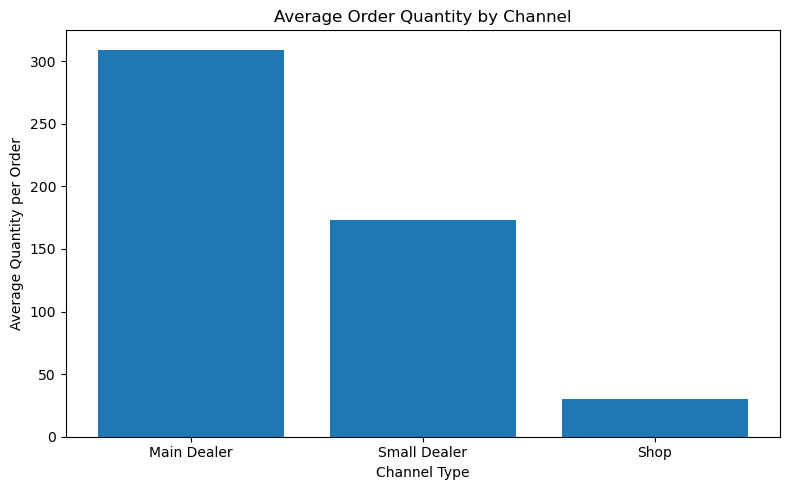

In [44]:
channel_mean_quantity = (
    df.groupby("Channel Type")["Quantity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    channel_mean_quantity.index,
    channel_mean_quantity.values
)

plt.title("Average Order Quantity by Channel")
plt.xlabel("Channel Type")
plt.ylabel("Average Quantity per Order")

plt.tight_layout()

plt.savefig(
    chart_folder / "08_Average_Order_Quantity_by_Channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Average order quantity differs across the recorded channel structures.

However, Shop and Small Dealer transactions occur in the earlier business regime, while Main Dealer transactions occur in the later regime.

Therefore, the observed differences should be interpreted as differences across historical channel structures rather than as direct causal effects of the sales channel.

### 12.9 Average Order Quantity by Market

This chart compares average Regular Order Quantity between the Local and Japan markets.

The comparison is descriptive because all Japan transactions are concentrated within one Main Dealer buyer and the post-April-2025 business regime.

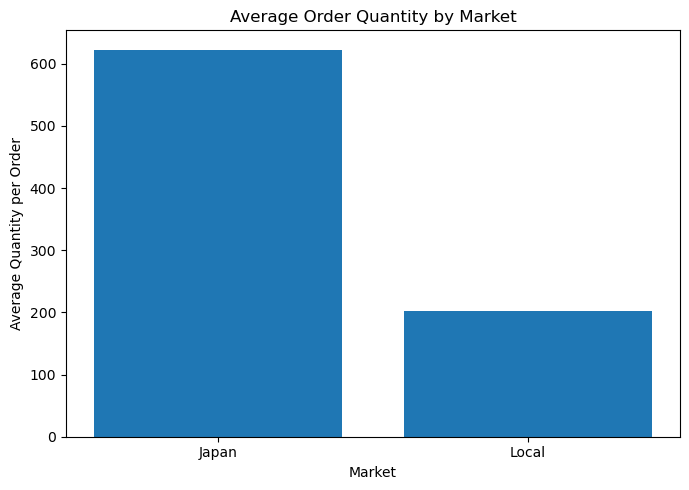

In [45]:
market_mean_quantity = (
    df.groupby("Export Market")["Quantity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

plt.bar(
    market_mean_quantity.index,
    market_mean_quantity.values
)

plt.title("Average Order Quantity by Market")
plt.xlabel("Market")
plt.ylabel("Average Quantity per Order")

plt.tight_layout()

plt.savefig(
    chart_folder / "09_Average_Order_Quantity_by_Market.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The chart shows a descriptive difference in average order quantity between Local and Japan Regular Orders.

This difference cannot be interpreted as an isolated market effect because the Japan observations are associated with one buyer, the Main Dealer channel, and the post-April-2025 regime.

The market comparison therefore describes the observed historical structure rather than establishing a causal market relationship.

### 12.10 Monthly Revenue Over Time

Monthly Regular Order revenue is plotted chronologically using Year-Month.

This chart provides a financial view of changes in business activity over the historical period.

In [46]:
monthly_revenue_plot = monthly_revenue.copy()

monthly_revenue_plot["Month_Date"] = pd.to_datetime(
    monthly_revenue_plot["Year_Month"] + "-01"
)

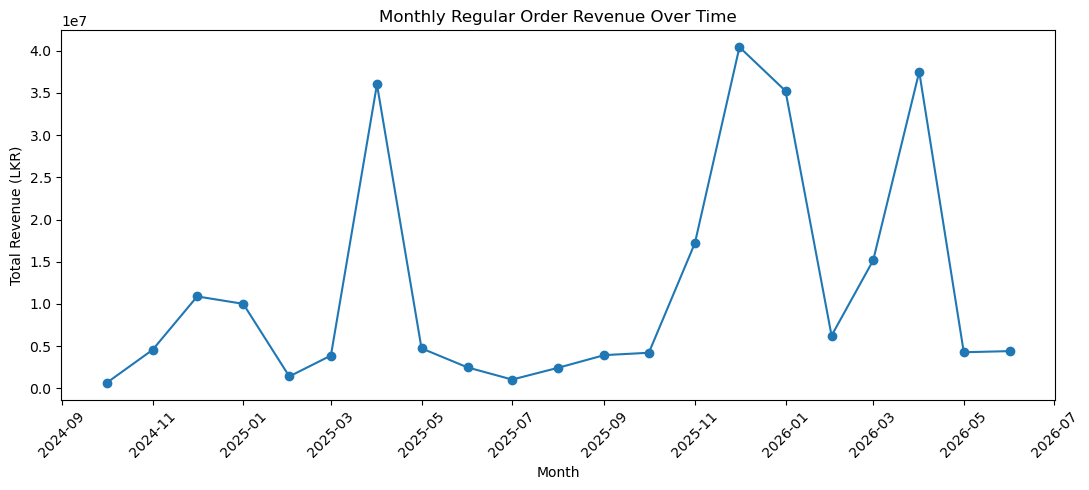

In [47]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_revenue_plot["Month_Date"],
    monthly_revenue_plot["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Regular Order Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue (LKR)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    chart_folder / "10_Monthly_Revenue_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Monthly revenue varies throughout the observed period.

Revenue changes reflect both order Quantity and the applicable pricing rules. Therefore, peaks and declines in revenue should not be interpreted as demand changes alone.

The revenue trend provides complementary business context to the Quantity-based demand analysis.

In [48]:
for file in sorted(chart_folder.glob("*.png")):
    print(file.name)

01_Total_Demand_by_Product.png
02_Average_Order_Quantity_by_Product.png
03_Monthly_Total_Demand_Over_Time.png
04_Monthly_Demand_by_Product.png
05_Quantity_Histogram.png
06_Quantity_Boxplot.png
07_Quantity_Boxplot_by_Product.png
08_Average_Order_Quantity_by_Channel.png
09_Average_Order_Quantity_by_Market.png
10_Monthly_Revenue_Over_Time.png


## 13. Summary of Descriptive Findings and Initial Business Insights

The descriptive analysis was performed using **3,116 Regular Orders** representing **705,810 units** of commercial demand. Free Samples were excluded from the main demand analysis because they do not represent normal commercial sales.

### 13.1 Overall Demand Characteristics

The mean Regular Order Quantity was **226.51 units**, while the median was **199.50 units**. The standard deviation was **183.88 units**, indicating substantial variability in commercial order size.

The middle 50% of Regular Orders ranged from **55 units (Q1)** to **354 units (Q3)**, producing an interquartile range of **299 units**. Order quantities ranged from **23 to 998 units**.

The mean being higher than the median, together with the presence of high-volume orders, indicates that the upper end of the distribution is influenced by relatively large transactions. This shows that a single average is not sufficient to describe Fragceylon's commercial ordering behaviour.

### 13.2 Product Demand

| Product | Regular Orders | Total Demand | Demand Share | Mean Order Quantity |
|---|---:|---:|---:|---:|
| Mesmerose | 975 | 215,866 | 30.58% | 221.40 |
| Kennedy | 851 | 193,932 | 27.48% | 227.89 |
| Dark Matrix | 670 | 154,120 | 21.84% | 230.03 |
| Secret Ambrosia | 620 | 141,892 | 20.10% | 228.86 |

Mesmerose contributed the largest share of total Regular Order demand at **30.58%**, followed by Kennedy at **27.48%**.

Average order quantities were relatively similar across the four products, ranging from approximately **221 to 230 units per order**. This indicates that differences in total product demand are influenced substantially by the number of orders recorded for each product, rather than by very large differences in average order size.

Product-level inventory planning should therefore consider both order frequency and typical order quantity. These differences remain descriptive and require formal statistical testing before concluding that underlying mean demand differs significantly among the four products.

### 13.3 Channel Demand

| Channel | Regular Orders | Total Demand | Demand Share | Mean Order Quantity |
|---|---:|---:|---:|---:|
| Main Dealer | 2,014 | 622,595 | 88.21% | 309.13 |
| Small Dealer | 351 | 60,766 | 8.61% | 173.12 |
| Shop | 751 | 22,449 | 3.18% | 29.89 |

Main Dealer transactions accounted for approximately **88.21%** of total Regular Order demand and had a substantially larger average order quantity than Shop or Small Dealer transactions.

However, Shop and Small Dealer observations belong to the pre-April-2025 regime, while Main Dealer observations belong to the post-April-2025 regime. Therefore, the differences represent a combination of channel structure and historical business-regime differences rather than an isolated causal channel effect.

### 13.4 Market Demand

| Market | Regular Orders | Total Demand | Demand Share | Mean Order Quantity |
|---|---:|---:|---:|---:|
| Local | 2,931 | 590,642 | 83.68% | 201.52 |
| Japan | 185 | 115,168 | 16.32% | 622.53 |

The Local market generated most total demand because it contained substantially more transactions.

Japan contained only **185 Regular Orders**, but the average Japan order was considerably larger at **622.53 units**, compared with **201.52 units** for Local transactions.

This is a high-volume ordering pattern, but all Japan observations are associated with one buyer, the Main Dealer channel, and the post-April-2025 regime. The difference should therefore be interpreted as an observed historical association rather than an isolated market effect.

### 13.5 Monthly and Historical Demand Patterns

Demand varied substantially across the observed historical period.

When calendar months were aggregated across years, **April** recorded the largest total Quantity at **210,758 units**. However, calendar-month totals should be interpreted cautiously because months are not equally represented in the dataset and because the business structure changed during the study period.

Chronological Year-Month analysis identified the highest recorded monthly commercial demand in:

- **December 2025 – 115,818 units**
- **April 2026 – 107,546 units**
- **January 2026 – 106,387 units**
- **April 2025 – 103,212 units**

The lowest Year-Month total occurred in **October 2024 – 1,556 units**, but October 2024 is only a partial observation month because the dataset begins on 18 October.

A substantial increase in average order size is visible from April 2025 onward, coinciding with the transition to the Main Dealer channel. This historical increase should therefore be interpreted together with the business-structure change rather than automatically as organic growth or seasonality.

### 13.6 Sales Regime

| Sales Regime | Regular Orders | Total Demand | Demand Share | Mean Order Quantity |
|---|---:|---:|---:|---:|
| Pre-April-2025 | 1,102 | 83,215 | 11.79% | 75.51 |
| Post-April-2025 | 2,014 | 622,595 | 88.21% | 309.13 |

The post-April-2025 period contains substantially larger average order quantities.

Because the regime change coincides with the transition to Main Dealer transactions, a simple comparison cannot separate the effect of time from the effect of the changed channel structure. This structural change must therefore be considered during later statistical inference and predictive modelling.

### 13.7 Revenue Characteristics

Total Regular Order revenue during the observed period was **LKR 246,708,257.80**.

The mean Regular Order transaction value was **LKR 79,174.67**, while the median was **LKR 68,208.00**.

Revenue by product was:

| Product | Total Revenue (LKR) | Revenue Share |
|---|---:|---:|
| Mesmerose | 75,529,324.60 | 30.61% |
| Kennedy | 67,786,469.50 | 27.48% |
| Dark Matrix | 53,821,303.40 | 21.82% |
| Secret Ambrosia | 49,571,160.30 | 20.09% |

Mesmerose generated the largest share of Regular Order revenue.

The revenue shares closely resemble the Quantity-demand shares because prices follow a structured pricing system and are relatively similar across products. Revenue is therefore treated as complementary business information rather than an independent measure of demand.

### 13.8 Demand Variability and Outliers

The IQR analysis identified **41 Regular Orders** above the upper outlier threshold of **802.5 units**.

These observations ranged from **810 to 998 units** and were all associated with:

- Japan
- Main Dealer
- buyer Prabath Liyanarachchi

The observations were retained because they were internally consistent and passed both the pricing-rule and Total Value validation checks.

Their presence indicates that Fragceylon occasionally receives very large commercial orders that may have important implications for inventory availability and purchasing preparation.

### 13.9 Initial Business Insights

1. **Commercial demand is highly variable.** Regular Order quantities range from 23 to 998 units, indicating substantial differences in order size.
2. **Mesmerose contributes the largest share of historical demand.** However, average order sizes are similar across the four products, making order frequency an important contributor to product-level demand differences.
3. **High-volume dealer orders dominate the later period.** Main Dealer demand is much larger, but this pattern is inseparable from the April 2025 business-structure change.
4. **Japan orders are substantially larger on average than Local orders.** This pattern is concentrated within one buyer and one channel/regime and must therefore be interpreted cautiously.
5. **Demand changes considerably over time.** Several high-demand periods are visible, but structural change prevents these patterns from being interpreted purely as seasonality.
6. **Large commercial orders are operationally important.** The retained high-Quantity observations show that occasional high-volume orders may create inventory pressure if not anticipated.
7. **Product, market, channel, and time warrant formal statistical investigation.** The descriptive results provide the basis for hypothesis testing in the next stage.


## 14. Task 3 Descriptive Analysis Conclusion

The descriptive analysis demonstrates that Fragceylon's commercial demand varies substantially across transactions, products, markets, channel structures, and time periods.

The four perfume products show different total-demand contributions, although their average order quantities are relatively similar. Larger descriptive differences are visible across channel structures and markets, particularly among Main Dealer and Japan transactions.

The analysis also identifies a substantial change in order behaviour following the April 2025 business-structure transition. This structural change is an important consideration for all subsequent statistical inference and modelling.

The descriptive findings provide the empirical foundation for the next stage of the project: **Task 4 – Statistical Inference**, where the observed differences in demand will be evaluated using appropriate statistical tests, effect sizes, assumptions, and business interpretation.

No predictive modelling has been performed in this notebook.
